##Real vs Fake image generation predictions.

Using CIFAKE dataset for the evaluation of an early AI generated image dataset

I will be implementing a resnet-18 model on the CIFAKE dataset

In [47]:
!pip install -q kagglehub

Import the kaggle dataset


In [48]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Download cifake dataset

In [49]:
dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Dataset downloaded to: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [50]:
print("\nTop-level files/folders:")
print(os.listdir(dataset_path))

possible_train = os.path.join(dataset_path, "train")
possible_test = os.path.join(dataset_path, "test")

if not os.path.exists(possible_train) or not os.path.exists(possible_test):
    for item in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item)
        if os.path.isdir(item_path):
            nested_train = os.path.join(item_path, "train")
            nested_test = os.path.join(item_path, "test")
            if os.path.exists(nested_train) and os.path.exists(nested_test):
                possible_train = nested_train
                possible_test = nested_test
                break

train_dir = possible_train
test_dir = possible_test

print("\nTrain dir:", train_dir)
print("Test dir:", test_dir)

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Could not find train directory at: {train_dir}")
if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Could not find test directory at: {test_dir}")

print("\nTrain classes/folders:", os.listdir(train_dir))
print("Test classes/folders:", os.listdir(test_dir))


Top-level files/folders:
['test', 'train']

Train dir: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train
Test dir: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test

Train classes/folders: ['FAKE', 'REAL']
Test classes/folders: ['FAKE', 'REAL']


Set the hyperparamters

In [51]:
BATCH_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
IMG_SIZE = 224
VAL_SPLIT = 0.3
NUM_WORKERS = 2
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)


Transforms

In [52]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Load dataset

In [53]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
print("\nClass names:", class_names)

# Split train into train + validation
train_size = int((1 - VAL_SPLIT) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

# Make validation use non-augmented transform
val_dataset.dataset.transform = test_transform

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Class names: ['FAKE', 'REAL']
Train size: 70000
Val size: 30000
Test size: 20000


Data loaders

In [54]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Resnet18 model

In [56]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer for binary classification
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 2)

model = model.to(device)
print("\nModel loaded: ResNet18")


Model loaded: ResNet18


Loss

In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Optional scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Training functions

In [58]:
def train_model(model, train_loader, validation_loader, criterion, optimizer, scheduler, num_epochs):
    best_model_weights = copy.deepcopy(model.state_dict())
    best_validation_acc = 0.0

    train_losses = []
    validation_loss = []
    train_accuracies = []
    validation_accuracy = []

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 40)

        # ---- Training ----
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)
            total_train += labels.size(0)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = running_corrects.double().item() / total_train

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in validation_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = running_corrects.double().item() / total_val

        train_losses.append(epoch_train_loss)
        validation_loss.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        validation_accuracy.append(epoch_val_acc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Validation   Loss: {epoch_val_loss:.4f} | Validation   Acc: {epoch_val_acc:.4f}")

        if epoch_val_acc > best_validation_acc:
            best_validation_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        scheduler.step()

    elapsed = time.time() - start_time
    print(f"\nTraining complete in {elapsed / 60:.2f} minutes")
    print(f"Best Validation Accuracy: {best_validation_acc:.4f}")

    model.load_state_dict(best_model_weights)
    return model, train_losses, validation_loss, train_accuracies, validation_accuracy


Training the model

In [59]:
model, train_losses, validation_loss, train_accuracies, validation_accuracy = train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    scheduler,
    NUM_EPOCHS
)



Epoch 1/10
----------------------------------------
Train Loss: 0.1259 | Train Acc: 0.9512
Validation   Loss: 0.0782 | Validation   Acc: 0.9721

Epoch 2/10
----------------------------------------
Train Loss: 0.0601 | Train Acc: 0.9774
Validation   Loss: 0.0675 | Validation   Acc: 0.9748

Epoch 3/10
----------------------------------------
Train Loss: 0.0395 | Train Acc: 0.9856
Validation   Loss: 0.0681 | Validation   Acc: 0.9748

Epoch 4/10
----------------------------------------
Train Loss: 0.0135 | Train Acc: 0.9961
Validation   Loss: 0.0523 | Validation   Acc: 0.9816

Epoch 5/10
----------------------------------------
Train Loss: 0.0067 | Train Acc: 0.9986
Validation   Loss: 0.0537 | Validation   Acc: 0.9818

Epoch 6/10
----------------------------------------
Train Loss: 0.0044 | Train Acc: 0.9990
Validation   Loss: 0.0567 | Validation   Acc: 0.9819

Epoch 7/10
----------------------------------------
Train Loss: 0.0026 | Train Acc: 0.9997
Validation   Loss: 0.0542 | Validation

Plotted

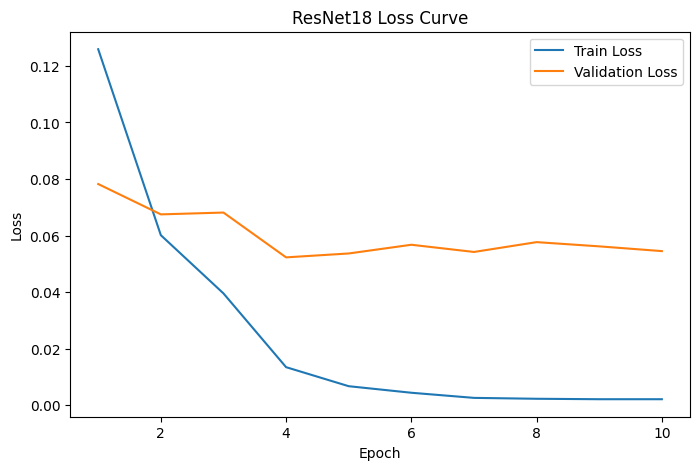

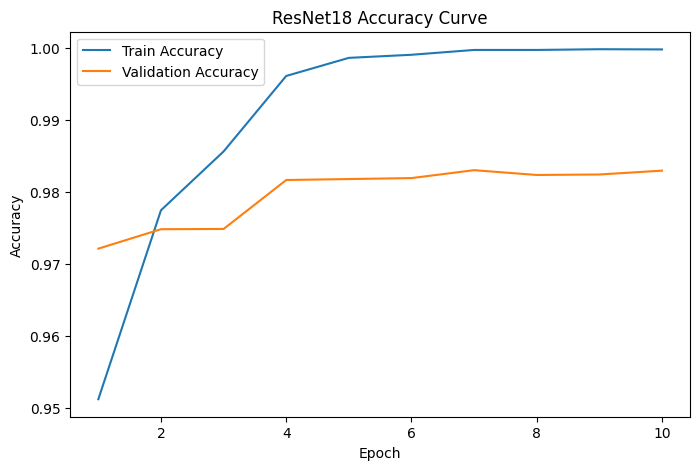

In [60]:
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Accuracy Curve")
plt.legend()
plt.show()


Evaluation on test set

In [61]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f}")


Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98     10000
        REAL       0.98      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000

Test Accuracy: 0.9818
